# Constraint experiments

Shared data and architecture; separate cells for none, soft, and hard constraints.
## DONT TAKE THIS TOO SERIOUSLY YET IDK WHY THE ERROR RATES ARE SO HIGH

In [1]:
%pip install -q numpy scipy matplotlib pandas torch scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import label as connected_components
from scipy.spatial import cKDTree
from skimage.measure import marching_cubes

DATA = Path("data/bunny_cross_sections.npz")
TRAIN_RES = 32
STEPS = 8
BASE_CHANNELS = 4
LEARNING_RATE = 2e-3
TRUNCATION = 0.1
SEED = 11
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_num_threads(max(1, min(8, torch.get_num_threads())))
print(DEVICE)

cpu


## Data

In [3]:
with np.load(DATA) as archive:
    target = torch.from_numpy(archive["sdf3d"].astype(np.float32))[None, None]
    observed_mask = torch.from_numpy(archive["observed_mask"].astype(np.float32))[None, None]
    observed_sdf2d = torch.from_numpy(archive["observed_sdf2d"].astype(np.float32))[None, None]
    observed_normal = torch.from_numpy(archive["observed_normal"].astype(np.float32))[None]
    u_obs = torch.from_numpy(archive["u_obs"].astype(np.float32))[None, None]

source_res = target.shape[-1]
if source_res != TRAIN_RES:
    size = (TRAIN_RES,) * 3
    target = F.interpolate(target, size=size, mode="trilinear", align_corners=True)
    observed_sdf2d = F.interpolate(observed_sdf2d, size=size, mode="trilinear", align_corners=True)
    observed_normal = F.interpolate(observed_normal, size=size, mode="trilinear", align_corners=True)
    u_obs = F.interpolate(u_obs, size=size, mode="trilinear", align_corners=True)
    if source_res % TRAIN_RES == 0:
        factor = source_res // TRAIN_RES
        observed_mask = F.max_pool3d(observed_mask, factor, factor)
    else:
        observed_mask = F.interpolate(observed_mask, size=size, mode="nearest")

observed_sdf2d *= observed_mask
observed_normal *= observed_mask
inputs = torch.cat((observed_mask, observed_sdf2d, observed_normal, u_obs), dim=1)

inputs = inputs.to(DEVICE)
target = target.to(DEVICE)
observed_mask = observed_mask.bool().to(DEVICE)
observed_sdf2d = observed_sdf2d.to(DEVICE)
u_obs = u_obs.to(DEVICE)

spacing = 2.0 / (TRAIN_RES - 1)
print({"input": tuple(inputs.shape), "target": tuple(target.shape), "observed_voxels": int(observed_mask.sum())})

{'input': (1, 6, 32, 32, 32), 'target': (1, 1, 32, 32, 32), 'observed_voxels': 7173}


## Shared model, losses, and metrics

In [4]:
class Block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        groups = min(4, out_channels)
        self.layers = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
            nn.Conv3d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
        )

    def forward(self, x):
        return self.layers(x)


class UNet3D(nn.Module):
    def __init__(self, in_channels=6, base=4):
        super().__init__()
        self.enc1 = Block(in_channels, base)
        self.enc2 = Block(base, 2 * base)
        self.bridge = Block(2 * base, 4 * base)
        self.pool = nn.MaxPool3d(2)
        self.up2 = nn.ConvTranspose3d(4 * base, 2 * base, 2, stride=2)
        self.dec2 = Block(4 * base, 2 * base)
        self.up1 = nn.ConvTranspose3d(2 * base, base, 2, stride=2)
        self.dec1 = Block(2 * base, base)
        self.out = nn.Conv3d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        bridge = self.bridge(self.pool(e2))
        d2 = self.dec2(torch.cat((self.up2(bridge), e2), dim=1))
        d1 = self.dec1(torch.cat((self.up1(d2), e1), dim=1))
        return self.out(d1)


def truncated_l1(prediction, truth, truncation=TRUNCATION):
    prediction = prediction.clamp(-truncation, truncation)
    truth = truth.clamp(-truncation, truncation)
    return F.l1_loss(prediction, truth)


def slice_bound_loss(prediction):
    excess = F.relu(prediction.abs() - observed_sdf2d.abs())
    return excess[observed_mask].mean()


def section_sign_loss(prediction):
    sign = torch.where(observed_sdf2d < 0, -1.0, 1.0)
    return F.softplus(-sign * prediction / 0.02)[observed_mask].mean()


def eikonal_loss(prediction):
    dx = torch.diff(prediction, dim=2)[:, :, :, :-1, :-1] / spacing
    dy = torch.diff(prediction, dim=3)[:, :, :-1, :, :-1] / spacing
    dz = torch.diff(prediction, dim=4)[:, :, :-1, :-1, :] / spacing
    gradient_norm = torch.sqrt(dx.square() + dy.square() + dz.square() + 1e-8)
    return (gradient_norm - 1).square().mean()


def masked_mean(values, mask):
    return values[mask].mean() if mask.any() else values.sum() * 0.0


def symmetric_difference_loss(prediction):
    on_mask = observed_mask & (observed_sdf2d.abs() <= spacing)
    off_mask = observed_mask & ~on_mask & ((prediction < 0) != (observed_sdf2d < 0))
    on_loss = masked_mean((prediction - observed_sdf2d).abs(), on_mask)
    off_loss = masked_mean((prediction - observed_sdf2d).square(), off_mask)
    return on_loss, off_loss


def minimum_surface_loss(prediction, beta):
    return torch.exp(-beta * prediction.abs()).mean()


@dataclass(frozen=True)
class Experiment:
    name: str
    constraint: str
    sdf_weight: float = 1.0
    bound_weight: float = 0.0
    section_weight: float = 0.0
    eikonal_weight: float = 0.0
    symmetric_weight: float = 0.0
    minimum_surface_weight: float = 0.0
    minimum_surface_beta: float = 100.0


def constrained_output(raw, constraint):
    if constraint == "hard":
        return u_obs * torch.tanh(raw)
    return raw


def run_experiment(config):
    torch.manual_seed(SEED)
    model = UNet3D(inputs.shape[1], BASE_CHANNELS).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = []
    for step in range(STEPS):
        optimizer.zero_grad()
        prediction = constrained_output(model(inputs), config.constraint)
        loss = prediction.sum() * 0.0
        terms = {}
        if config.sdf_weight:
            terms["sdf"] = truncated_l1(prediction, target)
            loss = loss + config.sdf_weight * terms["sdf"]
        if config.bound_weight:
            terms["bound"] = slice_bound_loss(prediction)
            loss = loss + config.bound_weight * terms["bound"]
        if config.section_weight:
            terms["section"] = section_sign_loss(prediction)
            loss = loss + config.section_weight * terms["section"]
        if config.symmetric_weight:
            terms["on"], terms["off"] = symmetric_difference_loss(prediction)
            loss = loss + config.symmetric_weight * (terms["on"] + terms["off"])
        if config.eikonal_weight:
            terms["eikonal"] = eikonal_loss(prediction)
            loss = loss + config.eikonal_weight * terms["eikonal"]
        if config.minimum_surface_weight:
            terms["minimum_surface"] = minimum_surface_loss(prediction, config.minimum_surface_beta)
            loss = loss + config.minimum_surface_weight * terms["minimum_surface"]
        loss.backward()
        optimizer.step()
        history.append({key: float(value.detach()) for key, value in {"total": loss, **terms}.items()})
    model.eval()
    with torch.no_grad():
        prediction = constrained_output(model(inputs), config.constraint)
    return {"config": config, "model": model, "prediction": prediction.detach(), "history": history}


def metrics(prediction):
    slice_excess = F.relu(prediction.abs() - observed_sdf2d.abs())[observed_mask]
    hard_excess = F.relu(prediction.abs() - u_obs)
    predicted_inside = prediction < 0
    true_inside = target < 0
    intersection = (predicted_inside & true_inside).sum()
    union = (predicted_inside | true_inside).sum().clamp_min(1)
    near_surface = target.abs() < 2 * spacing
    return {
        "mae": float(F.l1_loss(prediction, target)),
        "surface_mae": float((prediction - target).abs()[near_surface].mean()),
        "iou": float(intersection / union),
        "eikonal_error": float(eikonal_loss(prediction)),
        "slice_slab_excess": float(slice_excess.mean()),
        "slice_slab_violation_rate": float((slice_excess > 1e-5).float().mean()),
        "contour_envelope_max": float(hard_excess.max()),
    }


results = {}

## No constraint

In [5]:
results["none"] = run_experiment(Experiment("none", "none"))
results["none"]["history"][-1]

{'total': 0.06607034802436829, 'sdf': 0.06607034802436829}

## Soft plane bound

In [6]:
results["soft"] = run_experiment(Experiment("soft", "soft", bound_weight=2.0))
results["soft"]["history"][-1]

{'total': 0.14743922650814056,
 'sdf': 0.11994561553001404,
 'bound': 0.013746804557740688}

## Hard contour envelope

In [7]:
results["hard"] = run_experiment(Experiment("hard", "hard"))
results["hard"]["history"][-1]

{'total': 0.058416977524757385, 'sdf': 0.058416977524757385}

## Eikonal regularization

This ablation keeps the supervised SDF loss and adds

$$
\mathcal{L}_{\mathrm{eik}}
=
\mathbb{E}_{\mathbf{x}\in\Omega_{\mathrm{reg}}}
\left(\|\nabla_{\mathbf{x}}f(\mathbf{x})\|_2-1\right)^2,
\qquad
\mathcal{L}=\mathcal{L}_{\mathrm{SDF}}+10^{-3}\mathcal{L}_{\mathrm{eik}}.
$$

The term encourages the predicted field to behave like a true signed distance function.

In [8]:
results["eikonal"] = run_experiment(Experiment("eikonal", "none", eikonal_weight=1e-3))
results["eikonal"]["history"][-1]

{'total': 0.12490807473659515,
 'sdf': 0.11383026093244553,
 'eikonal': 11.077815055847168}

## CrossSDF symmetric-difference objective

Following [CrossSDF](https://arxiv.org/abs/2412.04120), define

$$
\Omega_{\mathrm{on}}=\{\mathbf{x}\in\Omega_{\mathrm{pl}}:f_{2D}(\mathbf{x})=0\},
$$

$$
\Omega_{\mathrm{off}}=\{\mathbf{x}\in\Omega_{\mathrm{pl}}:
f_{2D}(\mathbf{x})\neq0,\;\operatorname{sgn}f(\mathbf{x})\neq\operatorname{sgn}f_{2D}(\mathbf{x})\}.
$$

The slice error is evaluated only on the contour and where the predicted and observed classifications disagree:

$$
\mathcal{L}_{\mathrm{on}}=\mathbb{E}_{\Omega_{\mathrm{on}}}|f-f_{2D}|,
\qquad
\mathcal{L}_{\mathrm{off}}=\mathbb{E}_{\Omega_{\mathrm{off}}}(f-f_{2D})^2.
$$

The paper also suppresses unsupported surfaces with

$$
\mathcal{L}_{\mathrm{min}}=\mathbb{E}_{\Omega_{\mathrm{reg}}}e^{-\beta|f|},
$$

and combines the terms as

$$
\mathcal{L}=\mathcal{L}_{\mathrm{on}}+\mathcal{L}_{\mathrm{off}}
+10^{-3}\mathcal{L}_{\mathrm{eik}}+5\times10^{-2}\mathcal{L}_{\mathrm{min}},
\qquad \beta=100.
$$

Here the exact contour is approximated by a one-voxel SDF band, and the full voxel grid is used as $\Omega_{\mathrm{reg}}$. Ground-truth 3D SDF values are withheld from this training loss and used only for evaluation.

In [9]:
results["crosssdf"] = run_experiment(Experiment(
    "crosssdf",
    "none",
    sdf_weight=0.0,
    symmetric_weight=1.0,
    eikonal_weight=1e-3,
    minimum_surface_weight=5e-2,
    minimum_surface_beta=100.0,
))
results["crosssdf"]["history"][-1]

{'total': 0.1971854716539383,
 'on': 0.058059073984622955,
 'off': 0.10504164546728134,
 'eikonal': 30.63876724243164,
 'minimum_surface': 0.06891974061727524}

## Evaluation

In [10]:
summary = pd.DataFrame({name: metrics(result["prediction"]) for name, result in results.items()}).T
summary

,mae,surface_mae,iou,eikonal_error,slice_slab_excess,slice_slab_violation_rate,contour_envelope_max
none,0.372470,0.525877,0.302113,23.163567,0.323839,0.779451,1.571999
soft,0.425855,0.116934,0.084235,59.545322,0.011437,0.261536,1.544816
hard,0.247139,0.083611,0.299087,1.348530,0.030780,0.493796,0.000000
eikonal,0.419076,0.223451,0.129723,9.993431,0.093067,0.592221,1.164161
crosssdf,0.409076,0.125392,0.127909,24.102571,0.018269,0.323156,1.527482


## CrossSDF paper mesh metrics

For surface point sets $P$ and $Q$, with $d(\mathbf{x},Q)=\min_{\mathbf{q}\in Q}\|\mathbf{x}-\mathbf{q}\|_2$, we evaluate

$$
\operatorname{CD}(P,Q)=\frac{1}{2}\left(
\frac{1}{|P|}\sum_{\mathbf{p}\in P}d(\mathbf{p},Q)
+\frac{1}{|Q|}\sum_{\mathbf{q}\in Q}d(\mathbf{q},P)
\right),
$$

$$
\operatorname{HD}(P,Q)=\max\left\{
\max_{\mathbf{p}\in P}d(\mathbf{p},Q),
\max_{\mathbf{q}\in Q}d(\mathbf{q},P)
\right\}.
$$

Chamfer distance measures average surface discrepancy, Hausdorff distance captures the worst discrepancy, and connected components (CC) expose fragmentation or floaters. As in the paper, CD and HD are reported $\times100$. Here zero sets are extracted by marching cubes; CC is a 26-neighbour voxel approximation.

In [11]:
def sample_zero_surface(field, count=12000, seed=SEED):
    volume = field.detach().cpu().numpy().squeeze()
    if volume.min() > 0 or volume.max() < 0:
        return None
    vertices, faces, _, _ = marching_cubes(volume, level=0, spacing=(spacing,) * 3)
    triangles = vertices[faces]
    areas = 0.5 * np.linalg.norm(np.cross(triangles[:, 1] - triangles[:, 0], triangles[:, 2] - triangles[:, 0]), axis=1)
    rng = np.random.default_rng(seed)
    selected = rng.choice(len(faces), size=count, p=areas / areas.sum())
    triangle = triangles[selected]
    r1 = np.sqrt(rng.random(count))
    r2 = rng.random(count)
    return (1 - r1)[:, None] * triangle[:, 0] + (r1 * (1 - r2))[:, None] * triangle[:, 1] + (r1 * r2)[:, None] * triangle[:, 2]


def paper_mesh_metrics(prediction, reference_points, seed):
    predicted_points = sample_zero_surface(prediction, seed=seed)
    volume = prediction.detach().cpu().numpy().squeeze() < 0
    component_count = connected_components(volume, structure=np.ones((3, 3, 3), dtype=np.uint8))[1]
    if predicted_points is None:
        return {"chamfer_x100": np.inf, "hausdorff_x100": np.inf, "components": component_count}
    pred_to_ref = cKDTree(reference_points).query(predicted_points, workers=-1)[0]
    ref_to_pred = cKDTree(predicted_points).query(reference_points, workers=-1)[0]
    return {
        "chamfer_x100": 50 * (pred_to_ref.mean() + ref_to_pred.mean()),
        "hausdorff_x100": 100 * max(pred_to_ref.max(), ref_to_pred.max()),
        "components": component_count,
    }


reference_points = sample_zero_surface(target)
paper_summary = pd.DataFrame({
    name: paper_mesh_metrics(result["prediction"], reference_points, SEED + index + 1)
    for index, (name, result) in enumerate(results.items())
}).T
paper_summary.loc["ground truth", "components"] = connected_components(
    target.detach().cpu().numpy().squeeze() < 0,
    structure=np.ones((3, 3, 3), dtype=np.uint8),
)[1]
paper_summary

,chamfer_x100,hausdorff_x100,components
none,22.403594,112.365262,66.0
soft,21.263574,116.759505,1.0
hard,23.513498,103.193345,43.0
eikonal,22.095659,112.000362,23.0
crosssdf,20.505352,113.417319,3.0
ground truth,NaN,NaN,1.0


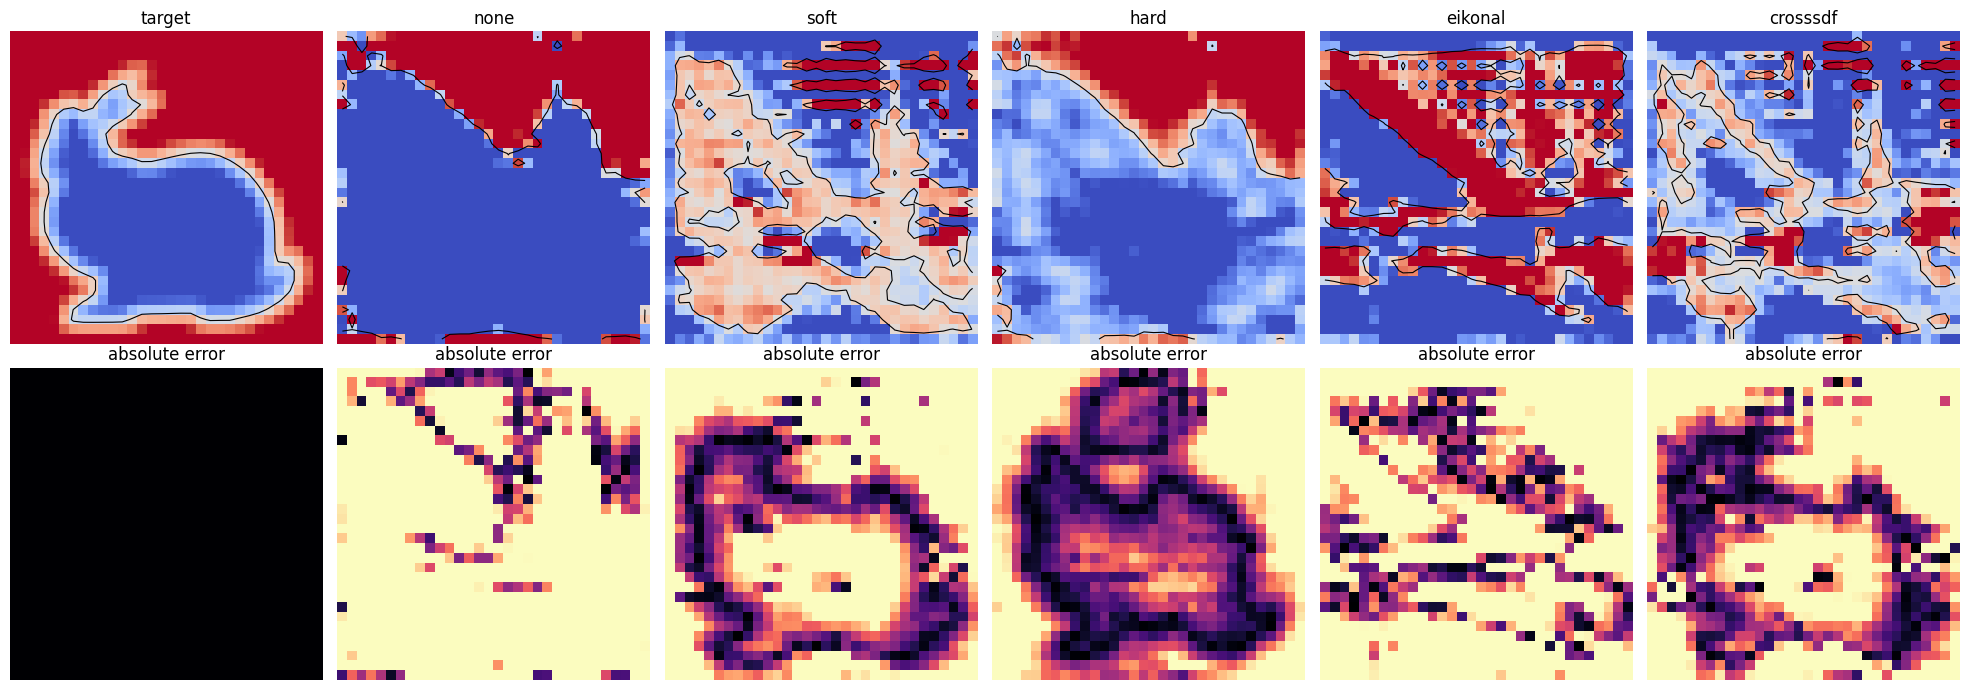

In [12]:
middle = TRAIN_RES // 2
fields = {"target": target, **{name: result["prediction"] for name, result in results.items()}}
fig, axes = plt.subplots(2, len(fields), figsize=(3.3 * len(fields), 7), squeeze=False)

for column, (name, field) in enumerate(fields.items()):
    image = field[0, 0, :, :, middle].detach().cpu().T
    axes[0, column].imshow(image, origin="lower", cmap="coolwarm", vmin=-TRUNCATION, vmax=TRUNCATION)
    axes[0, column].contour(image, levels=[0], colors="black", linewidths=0.8)
    axes[0, column].set_title(name)
    error = (field - target).abs()[0, 0, :, :, middle].detach().cpu().T
    axes[1, column].imshow(error, origin="lower", cmap="magma", vmin=0, vmax=0.2)
    axes[1, column].set_title("absolute error")
    axes[0, column].set_axis_off()
    axes[1, column].set_axis_off()

fig.tight_layout()
plt.show()

## Save results

In [13]:
output_dir = Path("data")
output_dir.mkdir(exist_ok=True)
summary.to_csv(output_dir / "constraint_metrics.csv")
paper_summary.to_csv(output_dir / "crosssdf_paper_metrics.csv")
predictions = {name: result["prediction"].cpu().numpy() for name, result in results.items()}
np.savez_compressed(
    output_dir / f"constraint_predictions_{TRAIN_RES}.npz",
    target=target.detach().cpu().numpy(),
    **predictions,
)